# 5. Clustering and Biological Interpretation

**Hierarchical clustering of G:** Average-linkage, correlation-distance clustering applied to the global response matrix G_rols (Notebook 3 ROLS output), following the HUVEC reference approach (`04_hierarchical_clustering_BMRA_Co-culture.ipynb`: `method="average"`, `metric="correlation"`, `scipy.cluster.hierarchy.linkage`/`fcluster`). Reveals co-regulatory modules, groups of genes whose inferred regulatory relationships cluster together.

For Stim8hr (`SKIP_BTLA=False`), the stim and BTLA axes share the same G matrix (ROLS produces one matrix per condition), so the BTLA clustermap and cross-axis hub comparison are skipped as redundant, `role_btla` annotation is still shown on the single clustermap. For Rest and Stim48hr (`SKIP_BTLA=True`), only the stim axis is processed throughout.

**Cross-condition external validation:** Loads the STRING/TRRUST validation summaries produced per-condition by Notebook 4 (Section 8) for all three conditions, and compares them side by side. Replaces the previous HUVEC structural baseline (different scale, not a gene-level benchmark) with a same-scale, statistically grounded comparison across Rest/Stim8hr/Stim48hr. A full temporal/cross-condition biological interpretation is deferred to a later notebook.

**Gene importance rankings:** Sum of squares per row of G (total outgoing regulatory influence, following the HUVEC reference `sqsum`/sum-of-squares ranking), mean |off-diagonal| strength per row (local importance; diagonal-based local importance is not used since G_not forces the diagonal to zero), and rank by |DPD_stim_norm|.

**GO enrichment:** Gene sets enriched using g:Profiler (GO:BP, GO:MF, KEGG, Reactome): top 50 by |DPD_stim_norm| split by direction (activators vs suppressors), shared cross-axis hubs, and per-cluster genes at N=4.

**Master gene table:** One row per core gene, combining DPD scores, edge inference, external validation (Notebook 4), and rankings/clusters/GO terms (this notebook) for discussing results with supervisors.

## Contents
1. Configuration
2. Load data
3. Hierarchical clustering (G matrix) — clustermap + standalone dendrogram
4. BTLA axis note
5. Cross-condition external validation summary
6. Gene importance rankings — table + top-N barplot
7. Cluster membership — table + cluster size barplot
8. GO enrichment — table + top-terms barplot
9. Master gene table
10. Save


### 1. Configuration

In [1]:
import os
print(f'Working directory: {os.getcwd()}')

Working directory: /mnt/R0/Projects/POIAZ/Ilaria/Scripts


In [2]:
# Must match Notebooks 1-4
CONDITION = 'Stim48hr' # 'Rest' | 'Stim8hr' | 'Stim48hr'
DONORS = ['D1', 'D2', 'D3', 'D4']
donors_tag = '_'.join(DONORS)
run_tag = f'{CONDITION}_{donors_tag}'

# BTLA: skip at Rest and Stim48hr, matches Notebooks 3 and 4
SKIP_BTLA = (CONDITION == 'Stim48hr' or CONDITION == 'Rest')

# ROLS outputs from Notebooks 3 and 4
INFERENCE_PATH = 'rols'

COND_DIR = f'../Results/{CONDITION}'
IN_DIR = os.path.join(COND_DIR, INFERENCE_PATH)
OUT_DIR = IN_DIR

# All conditions for cross-condition external validation comparison (Section 5)
ALL_CONDITIONS = ['Rest', 'Stim8hr', 'Stim48hr']

# Clustering
CLUSTER_METHOD = 'average'
CLUSTER_METRIC = 'correlation'
N_CLUSTERS_INTERP = 4 # for GO enrichment and interpretation
N_CLUSTERS_FULL = 8 # for comparison with HUVEC reference format
FIG_SIZE = (16, 14)

# GO enrichment
N_TOP_DPD = 50
GO_ORGANISM = 'hsapiens'
GO_SOURCES = ['GO:BP', 'GO:MF', 'KEGG', 'REAC']
GO_FDR = 0.05

print(f'run_tag: {run_tag}')
print(f'SKIP_BTLA: {SKIP_BTLA}')
print(f'Inference path: {INFERENCE_PATH}')
print(f'In dir: {IN_DIR}')


run_tag: Stim48hr_D1_D2_D3_D4
SKIP_BTLA: True
Inference path: rols
In dir: ../Results/Stim48hr/rols


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

try:
    from gprofiler import GProfiler
    GPROFILER_OK = True
except ImportError as e:
    GPROFILER_OK = False
    print(f'gprofiler-official not available ({e}). GO enrichment (Section 8) will be skipped.')
    print('Install with: pip install gprofiler-official --break-system-packages')

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

print('Packages loaded.')
print(f'GPROFILER_OK: {GPROFILER_OK}')


Packages loaded.
GPROFILER_OK: True


### 2. Load Data

In [4]:
# G matrix: one matrix covers both axes for a given condition
G_stim_df = pd.read_csv(os.path.join(IN_DIR, f'G_global_rols_{run_tag}.csv'), index_col=0)
if not SKIP_BTLA:
    G_btla_df = G_stim_df # same matrix, kept as alias for readability in BTLA-axis sections

# Node table from Notebook 4
nodes_df = pd.read_csv(os.path.join(IN_DIR, f'nodes_annotated_{run_tag}.csv'))

# Full DPD list for GO enrichment gene sets
dpd_full = pd.read_csv(os.path.join(COND_DIR, f'DPD_ranked_filtered_{run_tag}.csv'))

core_genes = G_stim_df.index.tolist()
N = len(core_genes)
node_idx = nodes_df.set_index('gene')

print(f'G_rols: {G_stim_df.shape}  range [{G_stim_df.values.min():.3f}, {G_stim_df.values.max():.3f}]')
print(f'Nodes: {len(nodes_df)}')
print(f'DPD full: {len(dpd_full):,} genes')


G_rols: (197, 197)  range [-1.199, 3.624]
Nodes: 197
DPD full: 6,373 genes


In [5]:
def make_role_colours(gene_list, node_table, role_col, pos_label, neg_label,
                      pos_colour='#d62728', neg_colour='#1f77b4'):
    roles = node_table[role_col].reindex(gene_list)
    colours = roles.map({pos_label: pos_colour, neg_label: neg_colour})
    return colours.fillna('#aaaaaa')

row_colours_stim = make_role_colours(
    core_genes, node_idx, 'role_stim', 'activator', 'suppressor')
print(f'Stim colours: {row_colours_stim.value_counts().to_dict()}')

if not SKIP_BTLA:
    row_colours_btla = make_role_colours(
        core_genes, node_idx, 'role_btla', 'btla_enhancer', 'btla_opposing',
        pos_colour='#9467bd', neg_colour='#2ca02c')
    print(f'BTLA colours: {row_colours_btla.value_counts().to_dict()}')


Stim colours: {'#1f77b4': 99, '#d62728': 98}


### 3. Hierarchical Clustering (G Matrix)

Average-linkage, correlation-distance clustering applied to `G_rols`. Row/column colour bars annotate `role_stim` (activator vs suppressor by `DPD_stim_norm`); for Stim8hr, `role_btla` is also available in `nodes_df` but the matrix itself is identical across axes, so only one clustermap is generated.


In [6]:
def make_clustermap(G_df, row_colours, title, method, metric, figsize):
    vals = G_df.values
    off_diag = vals[~np.eye(len(vals), dtype=bool)]
    vmax = float(np.percentile(np.abs(off_diag), 95))
    cg = sns.clustermap(
        G_df, method=method, metric=metric,
        cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
        row_colors=row_colours, col_colors=row_colours,
        figsize=figsize, xticklabels=True, yticklabels=True,
        dendrogram_ratio=(0.12, 0.12), colors_ratio=0.03, linewidths=0)
    cg.ax_heatmap.set_title(title, pad=12, fontsize=13, fontweight='bold')
    cg.ax_heatmap.set_xlabel('Target gene (column j)', fontsize=10)
    cg.ax_heatmap.set_ylabel('Source gene (row i)', fontsize=10)
    cg.ax_heatmap.tick_params(axis='both', labelsize=5)
    return cg

Generating stim clustermap...


/mnt/R0/Projects/POIAZ/Ilaria/Scripts/jupy_env_312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/mnt/R0/Projects/POIAZ/Ilaria/Scripts/jupy_env_312/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


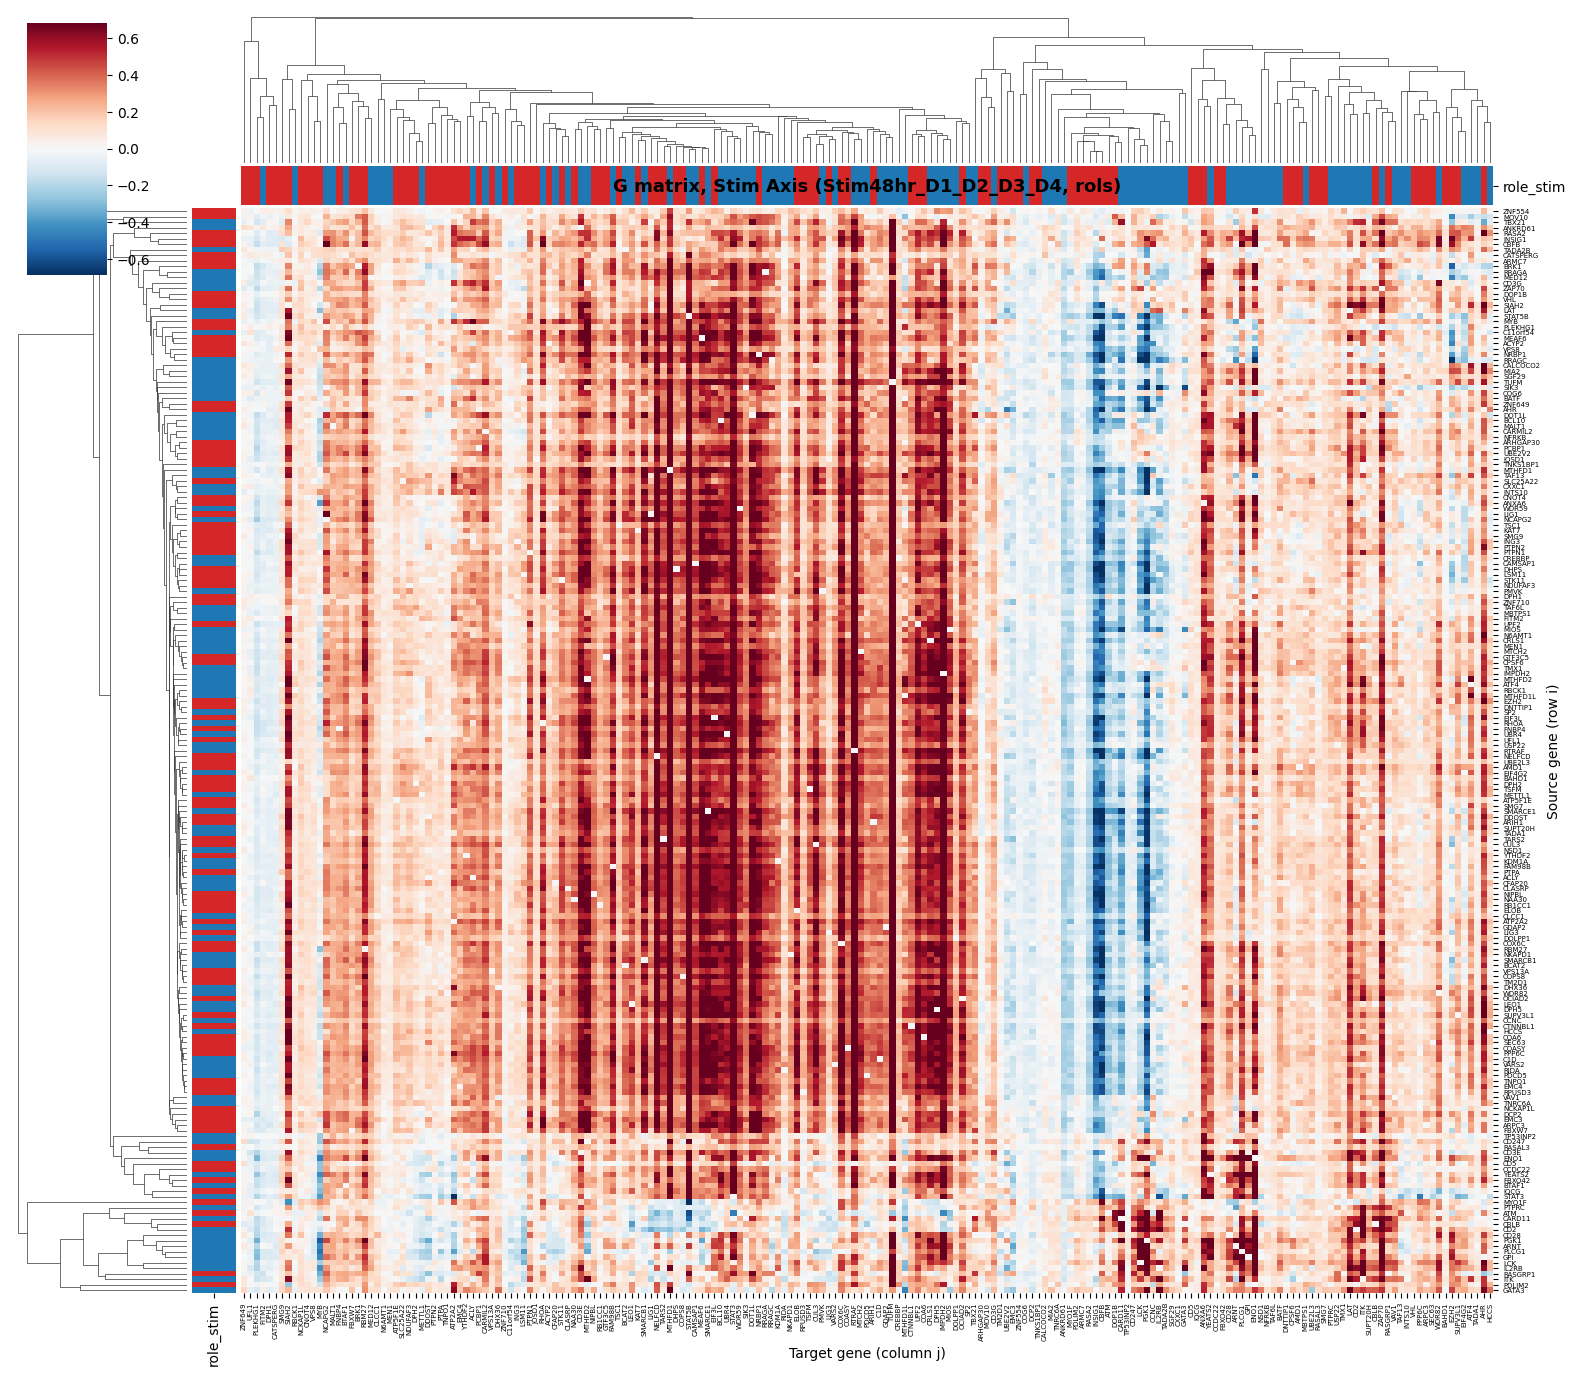

Saved: ../Results/Stim48hr/rols/clustermap_G_stim_Stim48hr_D1_D2_D3_D4.pdf
Saved: ../Results/Stim48hr/rols/clustermap_G_stim_Stim48hr_D1_D2_D3_D4.png


In [7]:
print('Generating stim clustermap...')
cg_stim = make_clustermap(
    G_stim_df, row_colours_stim,
    f'G matrix, Stim Axis ({run_tag}, {INFERENCE_PATH})',
    CLUSTER_METHOD, CLUSTER_METRIC, FIG_SIZE)
plt.show()

for ext, dpi in [('pdf', 150), ('png', 200)]:
    p = os.path.join(OUT_DIR, f'clustermap_G_stim_{run_tag}.{ext}')
    cg_stim.savefig(p, bbox_inches='tight', dpi=dpi)
    print(f'Saved: {p}')

stim_row_order = G_stim_df.index[cg_stim.dendrogram_row.reordered_ind].tolist()
G_stim_clustered = G_stim_df.loc[stim_row_order, stim_row_order]

Standalone dendrogram for the stim-axis row clustering above, following the HUVEC reference approach (`scipy.cluster.hierarchy.dendrogram` on the same `method`/`metric` linkage). Useful for inspecting cut points before choosing `N_CLUSTERS_INTERP`/`N_CLUSTERS_FULL`.

Saved: ../Results/Stim48hr/rols/dendrogram_stim_Stim48hr_D1_D2_D3_D4.png


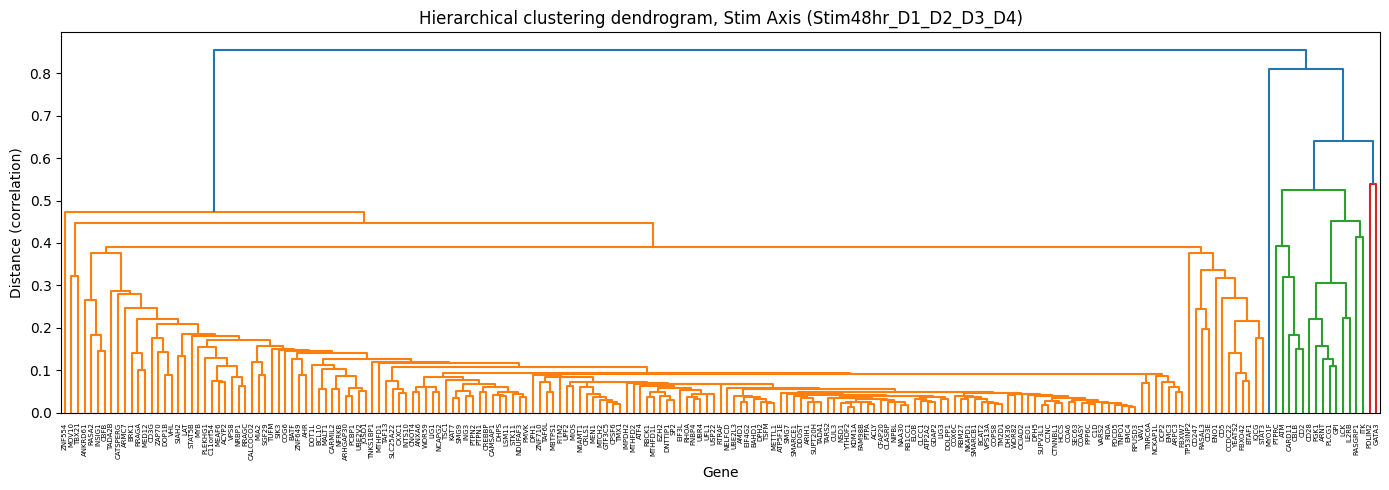

In [8]:
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(cg_stim.dendrogram_row.linkage, labels=G_stim_df.index.tolist(),
           leaf_rotation=90, leaf_font_size=5, ax=ax)
ax.set_title(f'Hierarchical clustering dendrogram, Stim Axis ({run_tag})')
ax.set_xlabel('Gene')
ax.set_ylabel(f'Distance ({CLUSTER_METRIC})')
plt.tight_layout()
p = os.path.join(OUT_DIR, f'dendrogram_stim_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
print(f'Saved: {p}')
plt.show()


### 4. BTLA Axis Note

ROLS produces a single G matrix per condition, so the BTLA-axis clustermap would be identical to the stim-axis clustermap above and is not regenerated. For Stim8hr, `role_btla` and `DPD_btla_norm` annotations remain available in `node_idx` / `nodes_df` for downstream interpretation (e.g. cluster membership in Section 6). For Rest and Stim48hr, BTLA columns are not meaningful (`SKIP_BTLA=True`).


In [9]:
# G_btla_clustered is not separately generated (see Section 4 note above);
# alias to the stim clustering result so downstream sections that reference
# both axes continue to work without modification.
G_btla_clustered = G_stim_clustered


### 5. Cross-Condition External Validation Summary

Loads the STRING/TRRUST validation tables produced by Notebook 4 (Section 8) for all three conditions (`ALL_CONDITIONS`, Section 1), not only the one set as `CONDITION` here -- this is the only point in the per-condition pipeline where conditions are compared directly. Replaces the previous HUVEC reference comparison (a structural check against a 13-node network at a different scale, not a gene-level benchmark) with a statistically grounded, same-scale comparison: does external validation strength track the expected biology across conditions (e.g. stronger at Stim8hr than Rest)?

A full temporal/cross-condition biological interpretation (clusters, hubs, GO terms across timepoints) is deferred to a later notebook; this section is a validation summary only. If Notebook 4 has not yet been run for one of the three conditions, that condition is skipped with a message rather than failing.


In [10]:
validation_by_condition = []
checkpoint_by_condition = []
for cond in ALL_CONDITIONS:
    cond_tag = f'{cond}_{donors_tag}'
    val_path = os.path.join(f'../Results/{cond}', INFERENCE_PATH, f'validation_string_trrust_{cond_tag}.csv')
    chk_path = os.path.join(f'../Results/{cond}', INFERENCE_PATH, f'validation_checkpoint_genes_{cond_tag}.csv')

    if os.path.exists(val_path):
        df = pd.read_csv(val_path)
        df.insert(0, 'condition', cond)
        validation_by_condition.append(df)
    else:
        print(f'{cond}: validation_string_trrust not found at {val_path} (run Notebook 4 for this condition first)')

    if os.path.exists(chk_path):
        cdf = pd.read_csv(chk_path)
        cdf.insert(0, 'condition', cond)
        checkpoint_by_condition.append(cdf)

validation_cross_condition = pd.concat(validation_by_condition, ignore_index=True) if validation_by_condition else pd.DataFrame()
checkpoint_cross_condition = pd.concat(checkpoint_by_condition, ignore_index=True) if checkpoint_by_condition else pd.DataFrame()

print(f'\nLoaded validation summaries: {len(validation_by_condition)}/{len(ALL_CONDITIONS)} conditions')
if not validation_cross_condition.empty:
    print(validation_cross_condition.to_string(index=False))



Loaded validation summaries: 3/3 conditions
condition  percentile axis  n_consensus_edges  string_highconf_overlap  string_highconf_pct  string_highconf_pval  string_medconf_overlap  string_medconf_pct  string_medconf_pval  trrust_overlap  trrust_pct  trrust_pval
     Rest          80 stim                 98                        7                  7.1          1.788471e-07                      10                10.2         1.815092e-06               1         1.0     0.032502
     Rest          90 stim                 44                        5                 11.4          1.095894e-06                       5                11.4         4.516328e-04               1         2.3     0.014715
     Rest          95 stim                 21                        3                 14.3          8.960864e-05                       3                14.3         3.442664e-03               1         4.8     0.007048
     Rest          99 stim                  1                        0     

Saved: ../Results/Stim48hr/rols/validation_cross_condition_Stim48hr_D1_D2_D3_D4.png


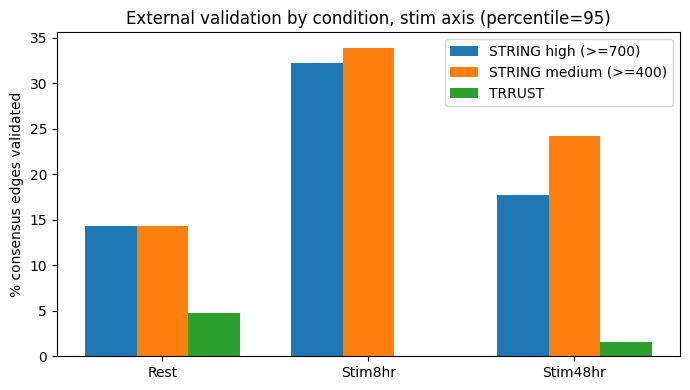


No checkpoint gene validation data found yet.


In [11]:
if not validation_cross_condition.empty:
    main_pct = 95
    plot_df = validation_cross_condition[
        (validation_cross_condition['percentile'] == main_pct) &
        (validation_cross_condition['axis'] == 'stim')]
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(7, 4))
        x = np.arange(len(plot_df))
        width = 0.25
        ax.bar(x - width, plot_df['string_highconf_pct'], width, label='STRING high (>=700)')
        ax.bar(x, plot_df['string_medconf_pct'], width, label='STRING medium (>=400)')
        ax.bar(x + width, plot_df['trrust_pct'], width, label='TRRUST')
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df['condition'])
        ax.set_ylabel('% consensus edges validated')
        ax.set_title(f'External validation by condition, stim axis (percentile={main_pct})')
        ax.legend()
        plt.tight_layout()
        p = os.path.join(OUT_DIR, f'validation_cross_condition_{run_tag}.png')
        plt.savefig(p, dpi=200, bbox_inches='tight')
        print(f'Saved: {p}')
        plt.show()
    else:
        print(f'No rows at percentile={main_pct}, axis=stim to plot.')
else:
    print('No validation summaries found yet for any condition; run Notebook 4 first.')

if not checkpoint_cross_condition.empty:
    print(f'\nCheckpoint gene edges across conditions ({len(checkpoint_cross_condition)} total):')
    print(checkpoint_cross_condition.to_string(index=False))
else:
    print('\nNo checkpoint gene validation data found yet.')


### 6. Gene Importance Rankings

In [12]:
def compute_rankings(G_df, node_table, dpd_col, label):
    genes = list(G_df.index)
    sos = (G_df.values ** 2).sum(axis=1)
    global_rank = pd.Series(sos, index=genes).rank(ascending=False).astype(int)

    # local_importance: mean |off-diagonal| strength per row, i.e. average magnitude of this
    # gene's direct influence on other genes. Diagonal-based local importance is not used here
    # since G_not (Notebook 3/4) forces the diagonal to zero by construction.
    off_diag_mask = ~np.eye(len(genes), dtype=bool)
    local_strength = np.array([
        np.abs(G_df.values[i, :][off_diag_mask[i, :]]).mean() for i in range(len(genes))
    ])
    local_rank = pd.Series(local_strength, index=genes).rank(ascending=False).astype(int)

    if dpd_col in node_table.columns:
        dpd_rank = node_table[dpd_col].reindex(genes).abs().rank(ascending=False).astype(int)
    else:
        dpd_rank = pd.Series(np.nan, index=genes)
    rankings = pd.DataFrame({'sum_of_squares': sos,
        'global_importance': global_rank,
        'mean_local_strength': local_strength,
        'local_importance': local_rank,
        'DPD_rank': dpd_rank}, index=genes).sort_values('global_importance')
    print(f'\n{label} top 20 by global importance:')
    print(rankings.head(20).to_string())
    return rankings

rankings_stim = compute_rankings(G_stim_df, node_idx, 'DPD_stim_norm', 'Stim')
if not SKIP_BTLA:
    rankings_btla = compute_rankings(G_btla_df, node_idx, 'DPD_btla_norm', 'BTLA')



Stim top 20 by global importance:
         sum_of_squares  global_importance  mean_local_strength  local_importance  DPD_rank
PPP6C         42.835271                  1             0.347004                 1       105
RTRAF         42.788295                  2             0.337657                 2        38
ATP2A2        40.985806                  3             0.333695                 3        30
SMARCB1       40.076786                  4             0.325222                 7        91
SMARCE1       39.663607                  5             0.313294                19        11
FAM98B        39.659971                  6             0.326167                 6        45
C1D           39.242422                  7             0.328048                 4        65
MTHFD1L       38.983808                  8             0.316191                15       100
CUL3          38.726452                  9             0.324724                 8        81
MTHFD2        38.653349                 10   

Saved: ../Results/Stim48hr/rols/top_genes_global_importance_stim_Stim48hr_D1_D2_D3_D4.png


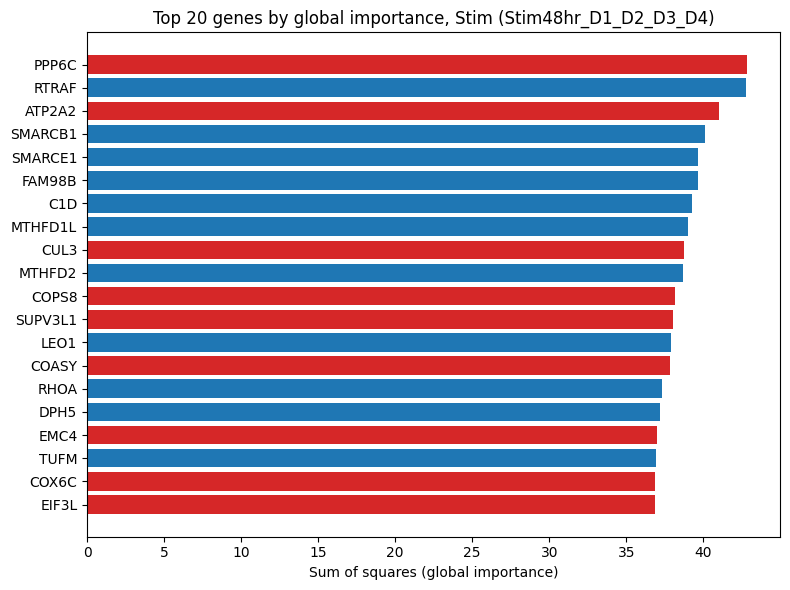

In [13]:
def plot_top_rankings(rankings, node_table, role_col, label, top_n=20):
    top = rankings.sort_values('sum_of_squares', ascending=False).head(top_n)
    roles = node_table[role_col].reindex(top.index) if role_col in node_table.columns else None
    colours = ['#d62728' if r in ('activator', 'btla_enhancer') else '#1f77b4'
               for r in (roles if roles is not None else [None] * len(top))]

    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.3)))
    ax.barh(top.index[::-1], top['sum_of_squares'][::-1], color=colours[::-1])
    ax.set_xlabel('Sum of squares (global importance)')
    ax.set_title(f'Top {top_n} genes by global importance, {label} ({run_tag})')
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'top_genes_global_importance_{label.lower()}_{run_tag}.png')
    plt.savefig(p, dpi=200, bbox_inches='tight')
    print(f'Saved: {p}')
    plt.show()

plot_top_rankings(rankings_stim, node_idx, 'role_stim', 'Stim')
if not SKIP_BTLA:
    plot_top_rankings(rankings_btla, node_idx, 'role_btla', 'BTLA')


In [14]:
if not SKIP_BTLA:
    top_q = N // 4
    stim_top = set(rankings_stim[rankings_stim['global_importance'] <= top_q].index)
    btla_top = set(rankings_btla[rankings_btla['global_importance'] <= top_q].index)
    shared_hubs = sorted(stim_top & btla_top)

    print(f'Top quartile stim: {len(stim_top)}, BTLA: {len(btla_top)}')
    print(f'Shared cross-axis hubs ({len(shared_hubs)} genes):')
    for g in shared_hubs:
        s = int(rankings_stim.loc[g, 'global_importance'])
        b = int(rankings_btla.loc[g, 'global_importance'])
        print(f'  {g:<15}  stim_rank={s:>3}  btla_rank={b:>3}')
else:
    shared_hubs = []
    print('SKIP_BTLA=True: cross-axis hub comparison skipped (single G matrix).')


SKIP_BTLA=True: cross-axis hub comparison skipped (single G matrix).


### 7. Cluster Membership

Two cuts: N=4 (interpretive, used for GO enrichment) and N=8 (comparison format matching the HUVEC reference). The cluster distribution from the previous pseudobulk run showed extreme imbalance at N=8 (cluster 1: 139 genes, four singletons). N=4 gives more meaningful decompositions. The right number depends on the dendrogram, inspect the clustermap above and adjust N_CLUSTERS_INTERP if needed.

In [15]:
def get_clusters(G_df, n_clusters, method, metric, label):
    genes = list(G_df.index)
    dist = pdist(G_df.values, metric=metric)
    Z = linkage(dist, method=method)
    labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    membership = pd.DataFrame({'gene': genes, f'cluster_{label}': labels}).sort_values(f'cluster_{label}')
    print(f'{label} cluster sizes (N={n_clusters}):')
    print(membership[f'cluster_{label}'].value_counts().sort_index().to_string())
    return membership

clusters_stim_4 = get_clusters(G_stim_df, N_CLUSTERS_INTERP, CLUSTER_METHOD, CLUSTER_METRIC, 'stim4')
print()
clusters_stim_8 = get_clusters(G_stim_df, N_CLUSTERS_FULL, CLUSTER_METHOD, CLUSTER_METRIC, 'stim8')

# BTLA clusters not computed separately: G matrix is identical to stim for ROLS,
# so cluster membership would also be identical.


stim4 cluster sizes (N=4):
cluster_stim4
1    180
2     14
3      2
4      1

stim8 cluster sizes (N=8):
cluster_stim8
1    179
2      1
3      5
4      7
5      2
6      1
7      1
8      1


Saved: ../Results/Stim48hr/rols/cluster_sizes_Stim48hr_D1_D2_D3_D4.png


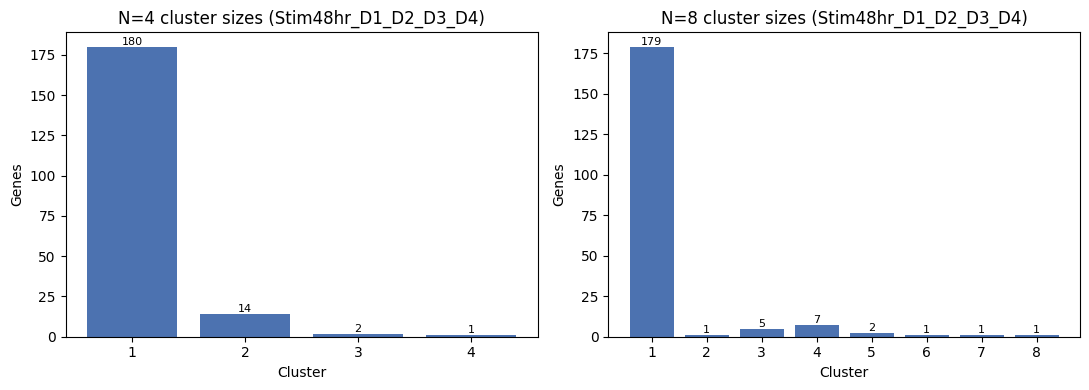

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (df, col, n) in zip(axes,
        [(clusters_stim_4, 'cluster_stim4', N_CLUSTERS_INTERP),
         (clusters_stim_8, 'cluster_stim8', N_CLUSTERS_FULL)]):
    sizes = df[col].value_counts().sort_index()
    ax.bar(sizes.index.astype(str), sizes.values, color='#4C72B0')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Genes')
    ax.set_title(f'N={n} cluster sizes ({run_tag})')
    for i, v in enumerate(sizes.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
p = os.path.join(OUT_DIR, f'cluster_sizes_{run_tag}.png')
plt.savefig(p, dpi=200, bbox_inches='tight')
print(f'Saved: {p}')
plt.show()


In [17]:
cluster_table = clusters_stim_4.merge(clusters_stim_8, on='gene')
extra = [c for c in ['DPD_stim_norm', 'DPD_btla_norm', 'role_stim', 'role_btla',
                      'out_stim', 'in_stim', 'out_btla', 'in_btla']
         if c in node_idx.columns]
cluster_table = cluster_table.merge(node_idx[extra].reset_index(), on='gene', how='left')
print(f'Cluster table: {cluster_table.shape}')
print(cluster_table.head(10).to_string(index=False))


Cluster table: (197, 11)
    gene  cluster_stim4  cluster_stim8  DPD_stim_norm  DPD_btla_norm role_stim     role_btla  out_stim  in_stim  out_btla  in_btla
  ATP2A2              1              1       2.484608      -0.375743 activator btla_opposing         0        0         0        0
  YTHDF2              1              1       1.586925       0.120207 activator btla_enhancer         0        0         0        0
   DOP1B              1              1       1.400565       0.384757 activator btla_enhancer         0        2         0        0
    CUL3              1              1       1.200441      -0.243055 activator btla_opposing         0        0         0        0
   COPS8              1              1       1.008155       0.237774 activator btla_enhancer         0        0         0        0
   PPP6C              1              1       0.904473      -0.052639 activator btla_opposing         0        0         0        0
     CD5              1              1       0.824007     

### 8. GO Enrichment

Gene sets:
- **Set A:** top 50 by |DPD_stim_norm| split by direction (activators and suppressors separately)
- **Set B:** shared cross-axis hub genes (top quartile global importance on both axes), only computed for Stim8hr where stim and BTLA z-score edge lists differ; empty for Rest and Stim48hr
- **Set C:** per-cluster genes at N=4 stim clusters (minimum 5 genes per cluster)

Uses g:Profiler API via `gprofiler-official`. No local database required. `no_iea=True` excludes inferred electronic annotations (cleaner results).


In [18]:
def run_go(gene_list, label, n_top=20):
    if not GPROFILER_OK:
        print(f'gprofiler not available, skipping {label}.')
        return pd.DataFrame()
    if len(gene_list) < 3:
        print(f'{label}: fewer than 3 genes, skipping.')
        return pd.DataFrame()
    gp = GProfiler(return_dataframe=True)
    try:
        res = gp.profile(
            organism=GO_ORGANISM,
            query=gene_list,
            sources=GO_SOURCES,
            significance_threshold_method='fdr',
            user_threshold=GO_FDR,
            no_iea=True,
            no_evidences=False, # needed to get the 'intersections' column (actual overlapping genes)
            ordered=False)
    except Exception as e:
        print(f'{label}: g:Profiler query failed: {e}')
        return pd.DataFrame()
    if res.empty:
        print(f'{label}: no significant terms at FDR <= {GO_FDR}')
        return pd.DataFrame()
    # Select columns defensively: gprofiler-official's column set has changed across versions
    # (e.g. 'intersections' requires no_evidences=False and may still be absent on some versions),
    # so missing columns are skipped rather than raising a KeyError.
    wanted_cols = ['source', 'native', 'name', 'p_value',
                   'term_size', 'query_size', 'intersection_size', 'intersections']
    available_cols = [c for c in wanted_cols if c in res.columns]
    missing_cols = [c for c in wanted_cols if c not in res.columns]
    if missing_cols:
        print(f'{label}: columns not returned by this gprofiler version (skipped): {missing_cols}')
    res = res[available_cols].copy()
    res = res.sort_values('p_value').head(n_top)
    res.insert(0, 'query_label', label)
    print(f'{label}, {len(res)} terms:')
    display_cols = [c for c in ['source', 'name', 'p_value', 'intersection_size'] if c in res.columns]
    print(res[display_cols].to_string(index=False))
    return res


In [19]:
# Set A top 50 DPD genes by direction
dpd_sorted = dpd_full.dropna(subset=['DPD_stim_norm']).copy()
dpd_sorted['abs_dpd'] = dpd_sorted['DPD_stim_norm'].abs()
top50 = dpd_sorted.nlargest(N_TOP_DPD, 'abs_dpd')
top50_act = top50[top50['DPD_stim_norm'] > 0]['target_contrast_gene_name'].tolist()
top50_sup = top50[top50['DPD_stim_norm'] < 0]['target_contrast_gene_name'].tolist()
print(f'Top 50 DPD: {len(top50_act)} activators, {len(top50_sup)} suppressors')

go_act = run_go(top50_act, 'Top50_activators')
go_sup = run_go(top50_sup, 'Top50_suppressors')

# Set B shared cross-axis hubs
print(f'\nShared hubs ({len(shared_hubs)} genes): {shared_hubs}')
go_hubs = run_go(shared_hubs, 'SharedHubs_bothAxes')

# Set C per-cluster enrichment (stim N=4)
go_cluster_results = []
for cid in sorted(clusters_stim_4['cluster_stim4'].unique()):
    cluster_genes = clusters_stim_4.loc[
        clusters_stim_4['cluster_stim4'] == cid, 'gene'].tolist()
    print(f'\nCluster stim4-{cid}: {len(cluster_genes)} genes')
    if len(cluster_genes) < 5:
        print('  Skipping (fewer than 5 genes)')
        continue
    res = run_go(cluster_genes, f'StimCluster_{cid}')
    if not res.empty:
        go_cluster_results.append(res)

go_clusters = pd.concat(go_cluster_results) if go_cluster_results else pd.DataFrame()

# Combined table
all_go = pd.concat(
    [df for df in [go_act, go_sup, go_hubs, go_clusters] if not df.empty],
    ignore_index=True)
print(f'\nTotal GO results: {len(all_go)} terms across '
      f'{all_go["query_label"].nunique() if not all_go.empty else 0} queries')

Top 50 DPD: 1 activators, 49 suppressors
Top50_activators: fewer than 3 genes, skipping.
Top50_suppressors, 20 terms:
source                                                               name      p_value  intersection_size
 GO:BP                          positive regulation of biological process 2.268341e-15                 44
  KEGG                                  T cell receptor signaling pathway 6.635432e-15                 14
 GO:BP                                  T cell receptor signaling pathway 9.232265e-15                 13
 GO:BP                            positive regulation of cellular process 1.653158e-14                 42
 GO:BP                        antigen receptor-mediated signaling pathway 3.271021e-13                 13
 GO:BP immune response-activating cell surface receptor signaling pathway 3.271021e-13                 15
 GO:BP immune response-regulating cell surface receptor signaling pathway 9.391424e-13                 15
 GO:BP                            

Top50_activators: no GO results to plot.
Saved: ../Results/Stim48hr/rols/GO_barplot_Top50_suppressors_Stim48hr_D1_D2_D3_D4.png


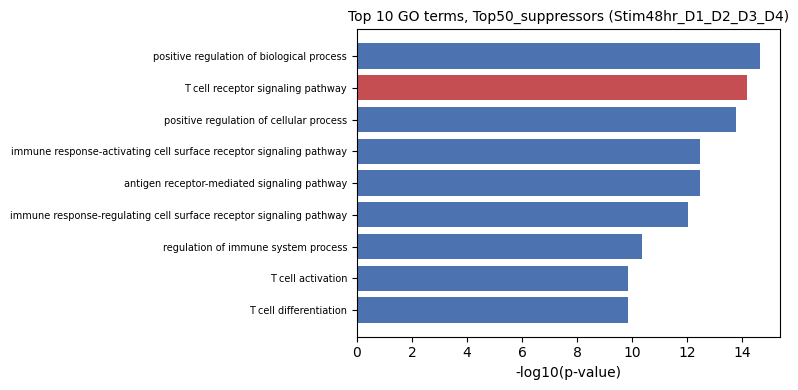

In [20]:
def plot_go_results(go_df, label, top_n=10):
    if go_df.empty:
        print(f'{label}: no GO results to plot.')
        return
    top = go_df.nsmallest(top_n, 'p_value').copy()
    top['neg_log10_p'] = -np.log10(top['p_value'].clip(lower=1e-300))
    top = top.sort_values('neg_log10_p')

    fig, ax = plt.subplots(figsize=(8, max(3, len(top) * 0.4)))
    colours = {'GO:BP': '#4C72B0', 'GO:MF': '#55A868', 'KEGG': '#C44E52', 'REAC': '#8172B2'}
    bar_colours = [colours.get(s, '#888888') for s in top['source']]
    ax.barh(top['name'], top['neg_log10_p'], color=bar_colours)
    ax.set_xlabel('-log10(p-value)')
    ax.set_title(f'Top {len(top)} GO terms, {label} ({run_tag})', fontsize=10)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    p = os.path.join(OUT_DIR, f'GO_barplot_{label}_{run_tag}.png')
    plt.savefig(p, dpi=200, bbox_inches='tight')
    print(f'Saved: {p}')
    plt.show()

plot_go_results(go_act, 'Top50_activators')
plot_go_results(go_sup, 'Top50_suppressors')
if not go_hubs.empty:
    plot_go_results(go_hubs, 'SharedHubs_bothAxes')


### 9. Master Gene Table

One row per core gene, combining DPD scores (Notebooks 1/2), edge inference and external validation (Notebook 4, via `nodes_df`), and rankings/cluster membership/GO terms (this notebook) into a single reference table for discussing results with supervisors.

GO term attribution is per-gene, not per-cluster: for each gene, only the GO terms it actually contributed to (via g:Profiler's `intersections`, i.e. the query genes that hit that term) are listed, across all four GO query sets run in Section 8 (top50 activators/suppressors, shared cross-axis hubs, per-cluster N=4) -- not just genes that happen to share a cluster with an enriched gene.


In [21]:
# Per-gene GO term attribution, inverted from all_go's 'intersections' column
gene_go_terms = {g: [] for g in core_genes}
if not all_go.empty and 'intersections' in all_go.columns:
    for _, row in all_go.iterrows():
        hits = row['intersections']
        if not isinstance(hits, list):
            continue
        term_str = f"{row['name']} ({row['query_label']}, p={row['p_value']:.2e})"
        for g in hits:
            if g in gene_go_terms:
                gene_go_terms[g].append(term_str)
else:
    print("No GO intersections available (gprofiler not run, or 'intersections' column missing); go_terms left empty.")

go_terms_series = pd.Series({g: '; '.join(terms) for g, terms in gene_go_terms.items()})
n_go_terms_series = pd.Series({g: len(terms) for g, terms in gene_go_terms.items()})
print(f'Genes with >=1 attributed GO term: {(n_go_terms_series > 0).sum()} / {len(core_genes)}')


Genes with >=1 attributed GO term: 164 / 197


In [22]:
master = nodes_df.copy()

rankings_stim_renamed = rankings_stim[['global_importance', 'mean_local_strength', 'local_importance']].copy()
rankings_stim_renamed.columns = [f'stim_{c}' for c in rankings_stim_renamed.columns]
master = master.merge(rankings_stim_renamed, left_on='gene', right_index=True, how='left')

if not SKIP_BTLA:
    rankings_btla_renamed = rankings_btla[['global_importance', 'mean_local_strength', 'local_importance']].copy()
    rankings_btla_renamed.columns = [f'btla_{c}' for c in rankings_btla_renamed.columns]
    master = master.merge(rankings_btla_renamed, left_on='gene', right_index=True, how='left')

master = master.merge(cluster_table[['gene', 'cluster_stim4', 'cluster_stim8']], on='gene', how='left')

master['go_terms'] = master['gene'].map(go_terms_series).fillna('')
master['n_go_terms'] = master['gene'].map(n_go_terms_series).fillna(0).astype(int)

master = master.sort_values(
    by=['is_checkpoint_gene', 'total_degree'], ascending=[False, False]
).reset_index(drop=True)

print(f'Master gene table: {master.shape}')
print(master.head(10).to_string(index=False))


Master gene table: (197, 29)
  gene  DPD_stim_norm  DPD_btla_norm  n_sig_genes  ontarget_significant  offtarget_flag  role_stim     role_btla  out_stim  in_stim  out_btla  in_btla  total_degree  G_influence  in_kegg_tcr  in_string_highconf  n_string_validated_edges_highconf  in_string_medconf  n_string_validated_edges_medconf  in_trrust  n_trrust_validated_edges  is_checkpoint_gene  stim_global_importance  stim_mean_local_strength  stim_local_importance  cluster_stim4  cluster_stim8                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

### 10. Save


In [23]:
# Clustered G matrix
G_stim_clustered.to_csv(os.path.join(OUT_DIR, f'G_stim_clustered_{run_tag}.csv'))
print('Saved: G_stim_clustered')

# Rankings
rankings_stim.to_csv(os.path.join(OUT_DIR, f'gene_rankings_stim_{run_tag}.csv'))
print('Saved: gene_rankings_stim')
if not SKIP_BTLA:
    rankings_btla.to_csv(os.path.join(OUT_DIR, f'gene_rankings_btla_{run_tag}.csv'))
    print('Saved: gene_rankings_btla')

# Cluster membership
cluster_table.to_csv(os.path.join(OUT_DIR, f'cluster_membership_{run_tag}.csv'), index=False)
print('Saved: cluster_membership')

# GO enrichment
if not all_go.empty:
    all_go.to_csv(os.path.join(OUT_DIR, f'GO_enrichment_{run_tag}.csv'), index=False)
    try:
        p_xlsx = os.path.join(OUT_DIR, f'GO_enrichment_{run_tag}.xlsx')
        with pd.ExcelWriter(p_xlsx) as w:
            for label, grp in all_go.groupby('query_label'):
                grp.to_excel(w, sheet_name=str(label)[:31], index=False)
        print(f'Saved: GO_enrichment.csv and .xlsx')
    except Exception as e:
        print(f'Excel export failed: {e} (CSV still saved)')

# Excel summary matching HUVEC reference format
try:
    p_xlsx = os.path.join(OUT_DIR, f'gene_rankings_{run_tag}.xlsx')
    with pd.ExcelWriter(p_xlsx) as w:
        rankings_stim.to_excel(w, sheet_name='stim_rankings')
        if not SKIP_BTLA:
            rankings_btla.to_excel(w, sheet_name='btla_rankings')
        cluster_table.to_excel(w, sheet_name='cluster_membership', index=False)
    print(f'Saved: gene_rankings.xlsx')
except Exception as e:
    print(f'Excel export failed: {e}')

# Master gene table
master_path = os.path.join(OUT_DIR, f'master_gene_table_{run_tag}.csv')
master.to_csv(master_path, index=False)
print(f'Saved: {master_path}')

print(f'\nAll outputs saved to {OUT_DIR}/')
if not SKIP_BTLA:
    print(f'  Shared cross-axis hubs: {len(shared_hubs)}')
print(f'  Top stim hub: {rankings_stim["global_importance"].idxmin()}')
if not SKIP_BTLA:
    print(f'  Top BTLA hub: {rankings_btla["global_importance"].idxmin()}')
print(f'  GO terms found: {len(all_go)}')


Saved: G_stim_clustered
Saved: gene_rankings_stim
Saved: cluster_membership
Saved: GO_enrichment.csv and .xlsx
Saved: gene_rankings.xlsx
Saved: ../Results/Stim48hr/rols/master_gene_table_Stim48hr_D1_D2_D3_D4.csv

All outputs saved to ../Results/Stim48hr/rols/
  Top stim hub: PPP6C
  GO terms found: 60
